# Model Training On Basketball Players Dataset

This notebook presents workflow using the target variable **`expectations_met_%`**.

We will cover:

1. **Data preprocessing**
   - Missing values handling
   - Duplicate removal
   - Outlier detection and handling
   - Data consistency correction
   - Format standardization
2. **Data transformation**
   - Categorical encoding
   - Feature scaling / normalization
   - Feature transformation
   - Feature engineering
   - Feature selection  
3. **Exploratory Data Analysis (EDA)** with visualizations 
4. **Training and comparing multiple regression models**
5. **Evaluation using several metrics and validation techniques**
6. **Inference function** for predicting insurance charges from user inputs

> Dataset file used: `nba_players_ml_dataset_550.csv`

In [ ]:
#importing libraries

import pandas as pd
from sklearn.model_selection import train_test_split


from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



## 1. Load the Dataset

In [ ]:
#showing the dataset used in this model

import os

data_path = "nba_players_ml_dataset_550.csv"
data = pd.read_csv(data_path)
print("Using dataset:", data_path)
print("Shape:", data.shape) 

display(data.head())



Using dataset: nba_players_ml_dataset_550.csv
Shape: (545, 10)


,height_cm,weight_kg,team,draft_pick,ppg,rpg,apg,spg,bpg,BPM
0,219,108,WAS,17,6.6,2.1,2.5,2.1,1.3,1.04
1,181,123,CLE,51,5.3,6.0,2.5,2.1,0.4,8.49
2,215,100,CLE,49,9.9,12.3,8.2,1.7,2.4,4.29
3,186,108,LAL,57,11.9,10.0,3.5,0.3,2.9,0.79
4,211,119,IND,33,6.4,0.2,5.4,2.4,1.6,-1.96


## 2. Quick Dataset Overview

We first inspect:
- data types
- missing values
- duplicates
- descriptive statistics


In [5]:
# Get summary of the data types and non-null counts
display(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   height_cm   545 non-null    int64  
 1   weight_kg   545 non-null    int64  
 2   team        545 non-null    str    
 3   draft_pick  545 non-null    int64  
 4   ppg         545 non-null    float64
 5   rpg         545 non-null    float64
 6   apg         545 non-null    float64
 7   spg         545 non-null    float64
 8   bpg         545 non-null    float64
 9   BPM         545 non-null    float64
dtypes: float64(6), int64(3), str(1)
memory usage: 44.3 KB


None

In [6]:
display(data.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
height_cm,545.0,NaN,NaN,NaN,200.726606,11.961509,180.0,190.0,201.0,211.0,221.0
weight_kg,545.0,NaN,NaN,NaN,102.711927,15.830663,75.0,89.0,104.0,116.0,130.0
team,545,30,TOR,28,NaN,NaN,NaN,NaN,NaN,NaN,NaN
draft_pick,545.0,NaN,NaN,NaN,32.042202,16.845428,1.0,18.0,33.0,47.0,60.0
ppg,545.0,NaN,NaN,NaN,16.305688,9.28004,0.1,8.5,15.9,24.5,31.9
rpg,545.0,NaN,NaN,NaN,6.889358,4.02054,0.0,3.4,6.7,10.2,14.0
apg,545.0,NaN,NaN,NaN,5.477615,3.179867,0.0,2.7,5.4,8.2,11.0
spg,545.0,NaN,NaN,NaN,1.29211,0.744337,0.0,0.6,1.4,1.9,2.5
bpg,545.0,NaN,NaN,NaN,1.481101,0.876171,0.0,0.7,1.4,2.3,3.0
BPM,545.0,NaN,NaN,NaN,2.16989,4.587041,-4.99,-1.96,1.72,6.4,9.96


## 3. Data Preprocessing

In this section we address:
- missing values
- duplicates
- data consistency
- format standardization
- outlier detection / handling

In [ ]:
# Missing values handling check

f_clean = data.copy()

missing_summary = data.isna().sum().to_frame("missing_count")
display(missing_summary)

print("Total missing values:", data.isna().sum().sum())

,missing_count
height_cm,0
weight_kg,0
team,0
draft_pick,0
ppg,0
rpg,0
apg,0
spg,0
bpg,0
BPM,0


Total missing values: 0


In [ ]:
# Removing duplicates

duplicates_before = data.duplicated().sum()
data_clean = data.drop_duplicates().reset_index(drop=True)
duplicates_after = data_clean.duplicated().sum()

print("Duplicates before removal:", duplicates_before)
print("Duplicates after removal:", duplicates_after)
print("New shape:", data_clean.shape)

Duplicates before removal: 0
Duplicates after removal: 0
New shape: (545, 10)


### Outlier Detection

We detect potential outliers with the **IQR rule** on numerical features.

Important note:
- In regression, not every statistical outlier should be removed.
- Some extreme values are **real and informative**, especially for medical charges.
- Therefore, we will **detect** outliers and then use a conservative strategy:
  - inspect them
  - optionally cap them instead of deleting them


In [ ]:
#checking for outliers

def iqr_outlier_summary(dataframe, columns):
    rows = []
    for col in columns:
        q1 = dataframe[col].quantile(0.25)
        q3 = dataframe[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        count = ((dataframe[col] < lower) | (dataframe[col] > upper)).sum()
        rows.append({
            "feature": col,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "lower_bound": lower,
            "upper_bound": upper,
            "outlier_count": int(count)
        })
    return pd.DataFrame(rows)

outlier_report = iqr_outlier_summary(data, ['height_cm', 'weight_kg', 
    'draft_pick', 'ppg', 'rpg', 'apg', 'spg', 'bpg', 'BPM'])
display(outlier_report)

,feature,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count
0,height_cm,190.00,211.0,21.00,158.50,242.50,0
1,weight_kg,89.00,116.0,27.00,48.50,156.50,0
2,draft_pick,18.00,47.0,29.00,-25.50,90.50,0
3,ppg,8.50,24.5,16.00,-15.50,48.50,0
4,rpg,3.40,10.2,6.80,-6.80,20.40,0
5,apg,2.70,8.2,5.50,-5.55,16.45,0
6,spg,0.60,1.9,1.30,-1.35,3.85,0
7,bpg,0.70,2.3,1.60,-1.70,4.70,0
8,BPM,-1.96,6.4,8.36,-14.50,18.94,0


In [ ]:
# Winsorization / capping using IQR bounds for selected numeric features

data_capped = data_clean.copy()

cap_cols = ["height_cm","weight_kg", 'draft_pick', 'ppg', 'rpg', 'apg', 'spg', 'bpg', 'BPM']

cap_bounds = {}
for col in cap_cols:
    q1 = data_capped[col].quantile(0.25)
    q3 = data_capped[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    cap_bounds[col] = (lower, upper)
    data_capped[col] = data_capped[col].clip(lower=lower, upper=upper)

print("Applied capping bounds:")
display(pd.DataFrame(cap_bounds, index=["lower", "upper"]).T)

Applied capping bounds:


,lower,upper
height_cm,158.50,242.50
weight_kg,48.50,156.50
draft_pick,-25.50,90.50
ppg,-15.50,48.50
rpg,-6.80,20.40
apg,-5.55,16.45
spg,-1.35,3.85
bpg,-1.70,4.70
BPM,-14.50,18.94


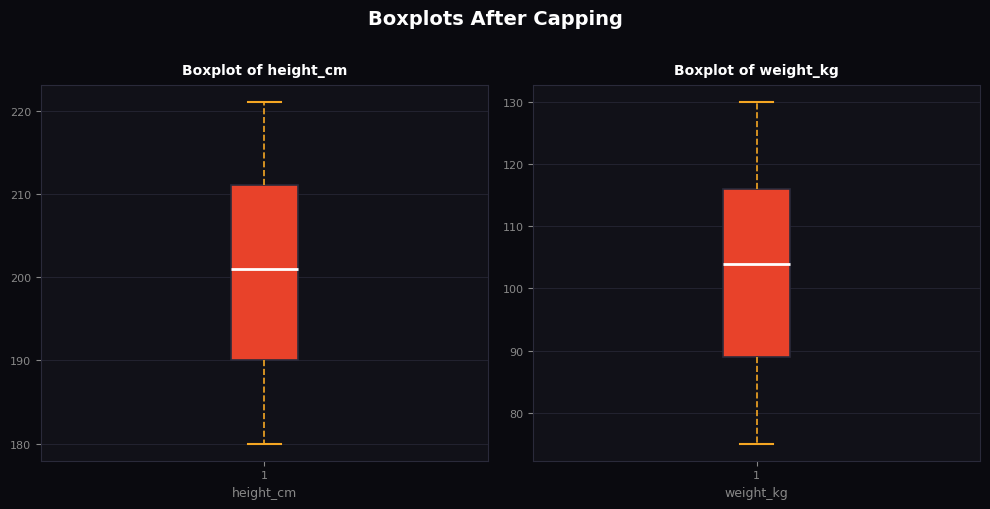

In [34]:
# Visualizations (Box Plots) after capping

fig = plt.figure(figsize=(10, 5))
fig.patch.set_facecolor('#0a0a0f')
fig.suptitle('Boxplots After Capping', color='white', fontsize=14, fontweight='bold', y=1.01)

for i, col in enumerate(['height_cm', 'weight_kg']):
    ax = fig.add_subplot(1, 2, i + 1)
    ax.set_facecolor('#111118')

    ax.boxplot(data_capped[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='#e8422a', color='#2a2a3a', linewidth=1.2),
               capprops=dict(color='#f5a623', linewidth=1.5),
               whiskerprops=dict(color='#f5a623', linewidth=1.2, linestyle='--'),
               medianprops=dict(color='white', linewidth=2),
               flierprops=dict(markeredgecolor='#888', marker='o', markersize=4, alpha=0.5))

    ax.set_title(f'Boxplot of {col}', color='white', fontsize=10, fontweight='bold', pad=8)
    ax.set_xlabel(col, color='#888', fontsize=9)
    ax.tick_params(colors='#888', labelsize=8)
    ax.xaxis.set_tick_params(labelcolor='#888')
    ax.yaxis.set_tick_params(labelcolor='#888')

    for spine in ax.spines.values():
        spine.set_edgecolor('#2a2a3a')

    ax.yaxis.grid(True, color='#2a2a3a', linewidth=0.5, zorder=0)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## Handling missing data

In [35]:
#if numerical value missing => median of the column

numerical_cols = ['height_cm', 'weight_kg', 
    'draft_pick', 
    'ppg', 'rpg', 'apg', 'spg', 'bpg', 'BPM']

imputer = SimpleImputer(strategy='median')
for col in numerical_cols:
    if data_capped[col].isna().sum() > 0:
        data_capped[[col]] = imputer.fit_transform(data_capped[[col]])    

        
#if categorical value missing => most frequent value in the column

categorical_cols = ['team']
imputer1 = SimpleImputer(strategy="most_frequent")
for ccol in categorical_cols:
    if data_capped[ccol].isna().sum() > 0:
        data_capped[[ccol]] = imputer1.fit_transform(data_capped[[ccol]])

data_capped.head()

,height_cm,weight_kg,team,draft_pick,ppg,rpg,apg,spg,bpg,BPM
0,219,108,WAS,17,6.6,2.1,2.5,2.1,1.3,1.04
1,181,123,CLE,51,5.3,6.0,2.5,2.1,0.4,8.49
2,215,100,CLE,49,9.9,12.3,8.2,1.7,2.4,4.29
3,186,108,LAL,57,11.9,10.0,3.5,0.3,2.9,0.79
4,211,119,IND,33,6.4,0.2,5.4,2.4,1.6,-1.96


### Encode Categorical features (team, by franchise ranking)

In [ ]:
# Custom Team Ranking(based on real life all time franchise ranking)

team_ranking = {
    'BOS': 1, 'LAL': 2, 'SAS': 3, 'PHI': 4, 'GSW': 5,
    'CHI': 6, 'MIA': 7, 'OKC': 8, 'DET': 9, 'NYK': 10,
    'MIL': 11, 'HOU': 12, 'POR': 13, 'ATL': 14, 'CLE': 15,
    'PHX': 16, 'DAL': 17, 'DEN': 18, 'UTA': 19, 'WAS': 20,
    'IND': 21, 'TOR': 22, 'SAC': 23, 'ORL': 24, 'BKN': 25,
    'LAC': 26, 'NOP': 27, 'MEM': 28, 'MIN': 29, 'CHA': 30
}

data['team_rank'] = data['team'].map(team_ranking)

# Show missing rankings only if they exist

missing = data[data['team_rank'].isnull()]
if not missing.empty:
    print("Missing rankings:")
    print(missing[['team']].drop_duplicates())
else:
    print("No missing rankings")

data['team_strength'] = 1 / (data['team_rank'])**2

# Show ranking table

print("\nTeam Ranking Table:")
print(data[['team', 'team_rank' ,'team_strength' ]].drop_duplicates().sort_values(by='team_rank'))



No missing rankings

Team Ranking Table:
   team  team_rank  team_strength
5   BOS          1       1.000000
3   LAL          2       0.250000
53  SAS          3       0.111111
10  PHI          4       0.062500
27  GSW          5       0.040000
40  CHI          6       0.027778
78  MIA          7       0.020408
38  OKC          8       0.015625
8   DET          9       0.012346
11  NYK         10       0.010000
69  MIL         11       0.008264
16  HOU         12       0.006944
34  POR         13       0.005917
12  ATL         14       0.005102
1   CLE         15       0.004444
23  PHX         16       0.003906
19  DAL         17       0.003460
26  DEN         18       0.003086
65  UTA         19       0.002770
0   WAS         20       0.002500
4   IND         21       0.002268
37  TOR         22       0.002066
83  SAC         23       0.001890
28  ORL         24       0.001736
55  BKN         25       0.001600
20  LAC         26       0.001479
7   NOP         27       0.001372
13  MEM

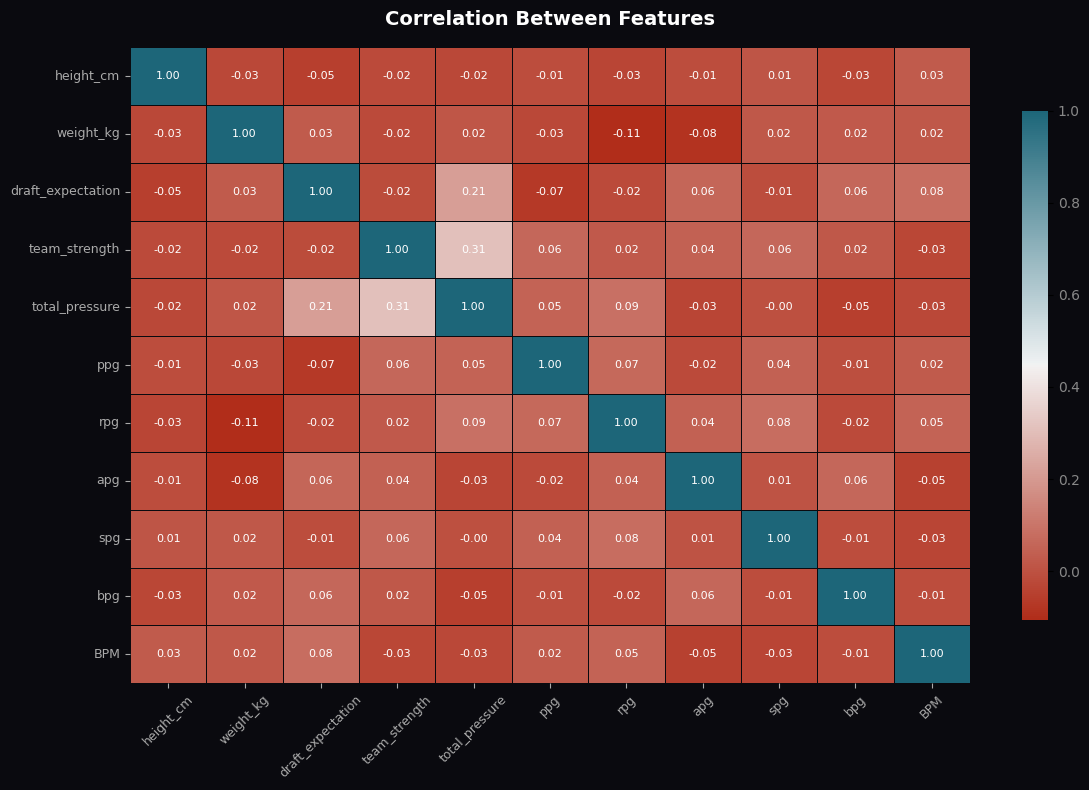

In [ ]:
#heatmap showuing corrolation between current columns/features

cols_to_corr = numerical_cols[:-1]

correlation_matrix = data[cols_to_corr].corr()

fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor('#0a0a0f')
ax.set_facecolor('#111118')

cmap = sns.diverging_palette(15, 220, s=90, l=40, as_cmap=True)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap=cmap,
    linewidths=0.5,
    linecolor='#0a0a0f',
    ax=ax,
    annot_kws={'size': 8, 'color': 'white'},
    cbar_kws={'shrink': 0.8}
)

ax.set_title('Correlation Between Features',
             color='white', fontsize=14, fontweight='bold', pad=16)

ax.tick_params(colors='#aaa', labelsize=9)
ax.xaxis.set_tick_params(labelcolor='#aaa', rotation=45)
ax.yaxis.set_tick_params(labelcolor='#aaa', rotation=0)

cbar = ax.collections[0].colorbar
cbar.ax.yaxis.set_tick_params(labelcolor='#888')
cbar.outline.set_edgecolor('#2a2a3a')

plt.tight_layout()
plt.show()

## 5. Feature Engineering

We will enrich the dataset with useful derived variables / interactions, for example:
- `BMI`
- Z-values
-Similarity and normalization variables

This are not mandatory, but it often improve model performance and interpretability.


In [ ]:
#bmi=w/h**2

height_m = data['height_cm'] / 100  
bmi = data['weight_kg'] / (height_m**2)
display(bmi.head())

0    22.518296
1    37.544641
2    21.633315
3    31.217482
4    26.728959
dtype: float64

In [ ]:
#we calculate the "sim" variable being how close you are to the ideal BMI using Gaussian similarity(=25.5, closest is 1)

data['sim'] = np.exp(-((bmi - 25.5)**2)/50)
display(data['sim'].head())

display(data['team_strength'].head())

data['draft_expectation'] = (1 / data['draft_pick']) ** 2
display(data['draft_expectation'].head())

0    0.837100
1    0.054943
2    0.741541
3    0.520070
4    0.970245
Name: sim, dtype: float64

0    0.002500
1    0.004444
2    0.004444
3    0.250000
4    0.002268
Name: team_strength, dtype: float64

0    0.003460
1    0.000384
2    0.000416
3    0.000308
4    0.000918
Name: draft_expectation, dtype: float64

In [ ]:
#ceating a pressure factor that effects players statistics based on how much pressure they have to play in(considering their team and draft pick)

data['pressure_factor'] = 0.4 + data['team_strength']


data['total_pressure'] = data['draft_expectation'] * data['team_strength']
display(data['total_pressure'].head())

data['pressure_scaled'] = (
    (data['total_pressure'] - data['total_pressure'].min()) /
    (data['total_pressure'].max() - data['total_pressure'].min())
)
display(data['pressure_scaled'].head())

0    0.000009
1    0.000002
2    0.000002
3    0.000077
4    0.000002
Name: total_pressure, dtype: float64

0    0.000033
1    0.000005
2    0.000006
3    0.000306
4    0.000007
Name: pressure_scaled, dtype: float64

In [18]:
data['ppg_adj'] = data['ppg'] * data['pressure_factor']
data['rpg_adj'] = data['rpg'] * data['pressure_factor']
data['apg_adj'] = data['apg'] * data['pressure_factor']
data['spg_adj'] = data['spg'] * data['pressure_factor']
data['bpg_adj'] = data['bpg'] * data['pressure_factor']
data['BPM_adj'] = data['BPM'] * data['pressure_factor']

stats = ['ppg_adj', 'rpg_adj', 'apg_adj', 'spg_adj', 'bpg_adj']

data[[s + '_z' for s in stats]] = (
    data[stats] - data[stats].mean()
) / data[stats].std()

Z_sum = data[[s + '_z' for s in stats]].sum(axis=1)
data['S'] = 1 / (1 + np.exp(-Z_sum))

bpm_mean, bpm_std = data['BPM'].mean(), data['BPM'].std()
data['sb'] = 1 / (1 + np.exp(-(data['BPM'] - bpm_mean) / bpm_std))

data['pressure_scaled_norm'] = (
    (data['pressure_scaled'] - data['pressure_scaled'].min()) /
    (data['pressure_scaled'].max() - data['pressure_scaled'].min())
)

data['sim_norm'] = (
    (data['sim'] - data['sim'].min()) /
    (data['sim'].max() - data['sim'].min())
)

## 5. Prepare Features and Target

In [19]:
#We find B (B being the expectations set on the player)
data['B'] = (0.6 * data['pressure_scaled_norm'] +
             0.4 * data['sim_norm'])

# scale to [0,1]
data['B'] = (
    (data['B'] - data['B'].min()) /
    (data['B'].max() - data['B'].min())
)
data['B'] = 0.2 + data['B'] 
data['B'] = np.maximum(data['B'], 0.05)*100
display(data['B'])

#A calculation(A being results)
data['A'] = ((0.5*data['sb'] + 0.5 * data['S'])) * data['pressure_factor']*100
display(data['A'])

0      53.537626
1      21.516098
2      49.623982
3      40.575557
4      58.986683
         ...    
540    37.246497
541    31.746192
542    57.197677
543    25.108707
544    40.826037
Name: B, Length: 545, dtype: float64

0      10.652850
1      17.779550
2      27.396967
3      43.670645
4       9.168421
         ...    
540    57.321266
541    11.350395
542    12.630705
543    13.882012
544    19.183772
Name: A, Length: 545, dtype: float64

In [20]:

data['expectation_met_%'] =  (data['A'] / data['B'])*100

data.to_csv("nba_players_ml_dataset_550_expectation.csv", index=False)


print(data[['expectation_met_%', 'A', 'B']].head())

   expectation_met_%          A          B
0          19.897875  10.652850  53.537626
1          82.633707  17.779550  21.516098
2          55.209126  27.396967  49.623982
3         107.627961  43.670645  40.575557
4          15.543204   9.168421  58.986683


In [21]:
df_feat = data.copy()

target_col = "expectation_met_%"

X = data.drop(columns=[target_col])
y = data[target_col]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
display(X.head())

Feature matrix shape: (545, 34)
Target shape: (545,)


,height_cm,weight_kg,team,draft_pick,ppg,rpg,apg,spg,bpg,BPM,...,rpg_adj_z,apg_adj_z,spg_adj_z,bpg_adj_z,S,sb,pressure_scaled_norm,sim_norm,B,A
0,219,108,WAS,17,6.6,2.1,2.5,2.1,1.3,1.04,...,-0.912570,-0.737076,0.462722,-0.316279,0.090605,0.438729,0.000033,0.834130,53.537626,10.652850
1,181,123,CLE,51,5.3,6.0,2.5,2.1,0.4,8.49,...,-0.310606,-0.734817,0.470897,-0.976265,0.080568,0.798640,0.000005,0.037704,21.516098,17.779550
2,215,100,CLE,49,9.9,12.3,8.2,1.7,2.4,4.29,...,0.659286,0.336412,0.147013,0.500626,0.741260,0.613535,0.000006,0.736827,49.623982,27.396967
3,186,108,LAL,57,11.9,10.0,3.5,0.3,2.9,0.79,...,1.239902,-0.147520,-0.839098,2.170039,0.918356,0.425356,0.000306,0.511316,40.575557,43.670645
4,211,119,IND,33,6.4,0.2,5.4,2.4,1.6,-1.96,...,-1.203688,-0.195268,0.703350,-0.096490,0.166856,0.288981,0.000007,0.969703,58.986683,9.168421


## 6. Exploratory Data Analysis (EDA)

We will explore:
- the distribution of the target `expectations_met_%`
- distributions of numerical features
- counts of categorical features
- relationships between features and target
- correlation structure among numerical features


In [22]:
numeric_cols = data.select_dtypes(include=np.number).columns.tolist()
categorical_cols = data.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['height_cm', 'weight_kg', 'draft_pick', 'ppg', 'rpg', 'apg', 'spg', 'bpg', 'BPM', 'team_rank', 'team_strength', 'sim', 'draft_expectation', 'pressure_factor', 'total_pressure', 'pressure_scaled', 'ppg_adj', 'rpg_adj', 'apg_adj', 'spg_adj', 'bpg_adj', 'BPM_adj', 'ppg_adj_z', 'rpg_adj_z', 'apg_adj_z', 'spg_adj_z', 'bpg_adj_z', 'S', 'sb', 'pressure_scaled_norm', 'sim_norm', 'B', 'A', 'expectation_met_%']
Categorical columns: ['team']


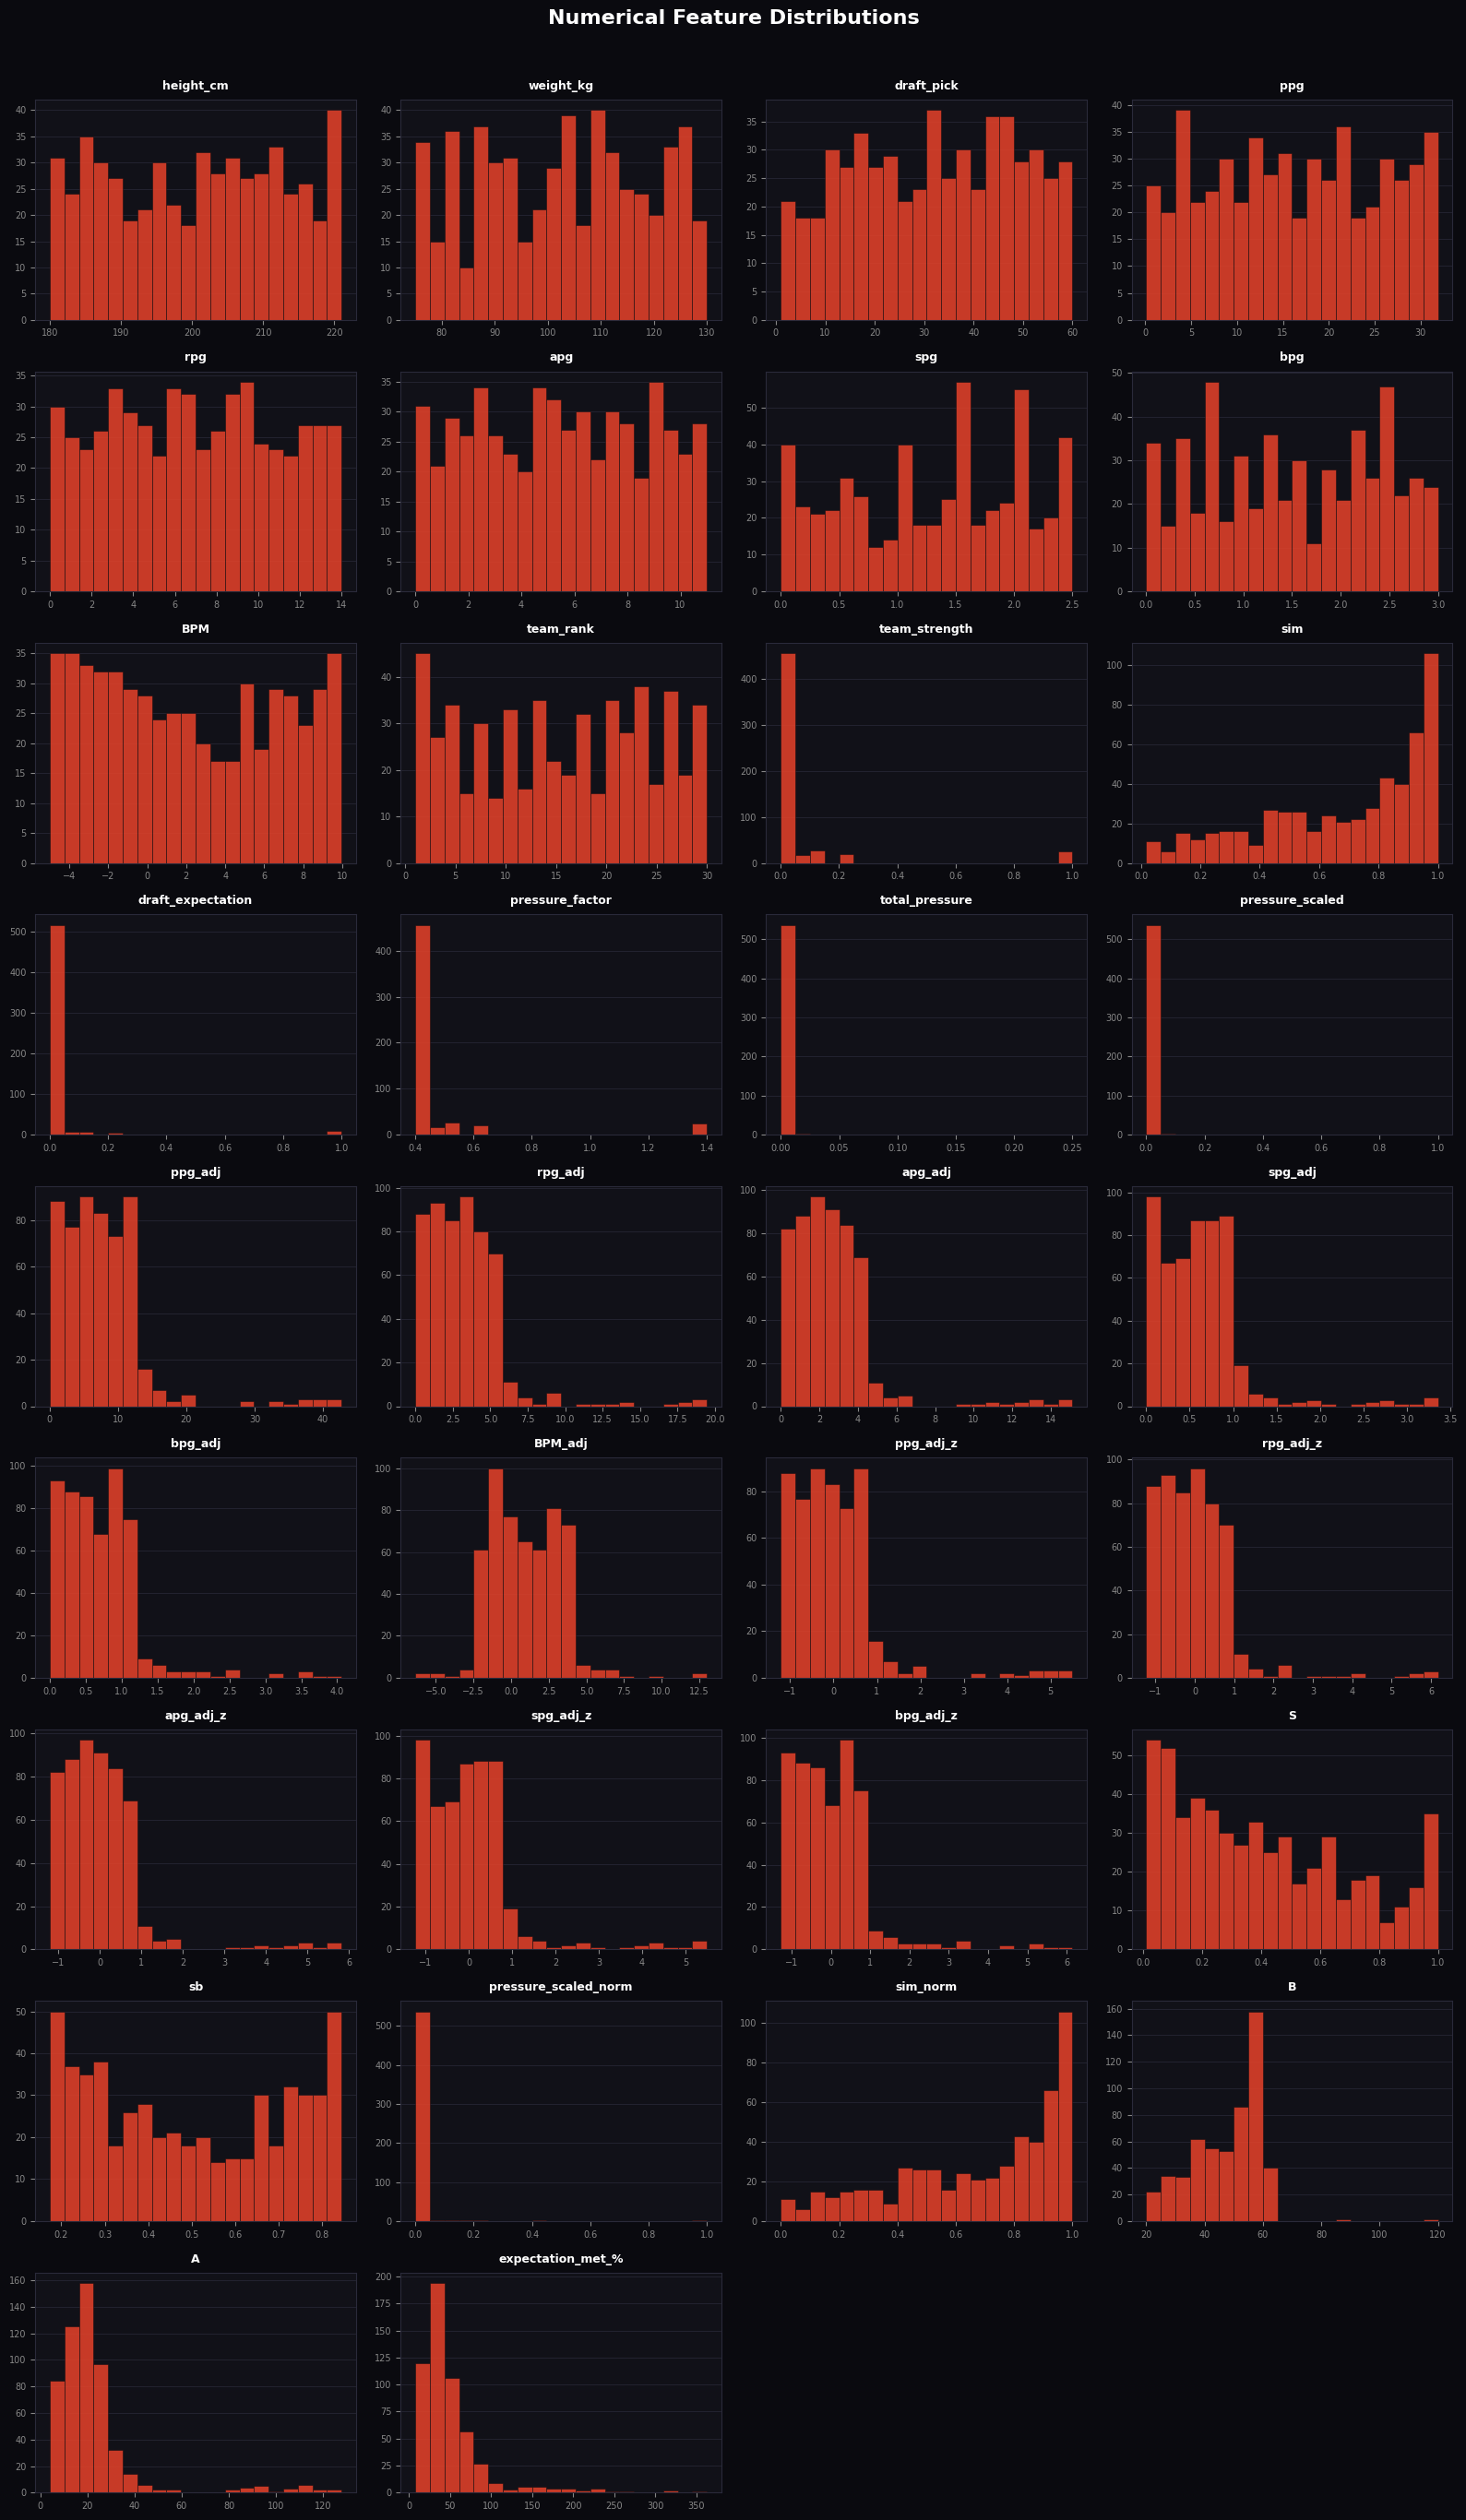

In [23]:
numeric_cols = data.select_dtypes(include='number').columns.tolist()

fig, axes = plt.subplots(nrows=(len(numeric_cols) + 3) // 4, ncols=4, figsize=(16, 3 * ((len(numeric_cols) + 3) // 4)))
fig.patch.set_facecolor('#0a0a0f')
fig.suptitle('Numerical Feature Distributions', color='white', fontsize=16, fontweight='bold', y=1.01)

axes_flat = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes_flat[i]
    ax.set_facecolor('#111118')
    ax.hist(data[col].dropna(), bins=20, color='#e8422a', alpha=0.85, edgecolor='#0a0a0f', linewidth=0.4)
    ax.set_title(col, color='white', fontsize=9, fontweight='bold', pad=8)
    ax.tick_params(colors='#888', labelsize=7)
    ax.xaxis.set_tick_params(labelcolor='#888')
    ax.yaxis.set_tick_params(labelcolor='#888')
    for spine in ax.spines.values():
        spine.set_edgecolor('#2a2a3a')
    ax.yaxis.grid(True, color='#2a2a3a', linewidth=0.5, zorder=0)
    ax.set_axisbelow(True)

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.show()

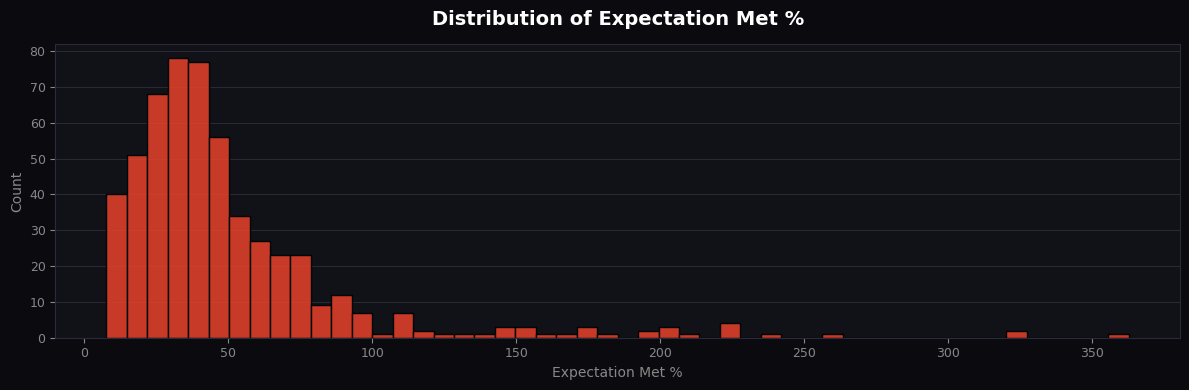

In [24]:
fig, ax = plt.subplots(figsize=(12, 4))
fig.patch.set_facecolor('#0a0a0f')
ax.set_facecolor('#111118')

sns.histplot(data['expectation_met_%'], bins=50, color='#e8422a', ax=ax, alpha=0.85)

ax.set_title('Distribution of Expectation Met %', color='white', fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Expectation Met %', color='#888', fontsize=10)
ax.set_ylabel('Count', color='#888', fontsize=10)

ax.tick_params(colors='#888', labelsize=9)
ax.xaxis.set_tick_params(labelcolor='#888')
ax.yaxis.set_tick_params(labelcolor='#888')

for spine in ax.spines.values():
    spine.set_edgecolor('#2a2a3a')

ax.yaxis.grid(True, color='#2a2a3a', linewidth=0.7, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

This distribution shows the number of players for each expectation percentage:

-We can the percentage with the most players assigned to it is between 25% and 60% , which clearly shows that people often misjudge players by metrics other than their contribution and most of the time those metric aren't acheived

-On the other end, we can clearly see that a really minor number of players have exceeded the expectations set onto them by either being on a lower-rank team or lower-number draft pick and be a really efficient player 

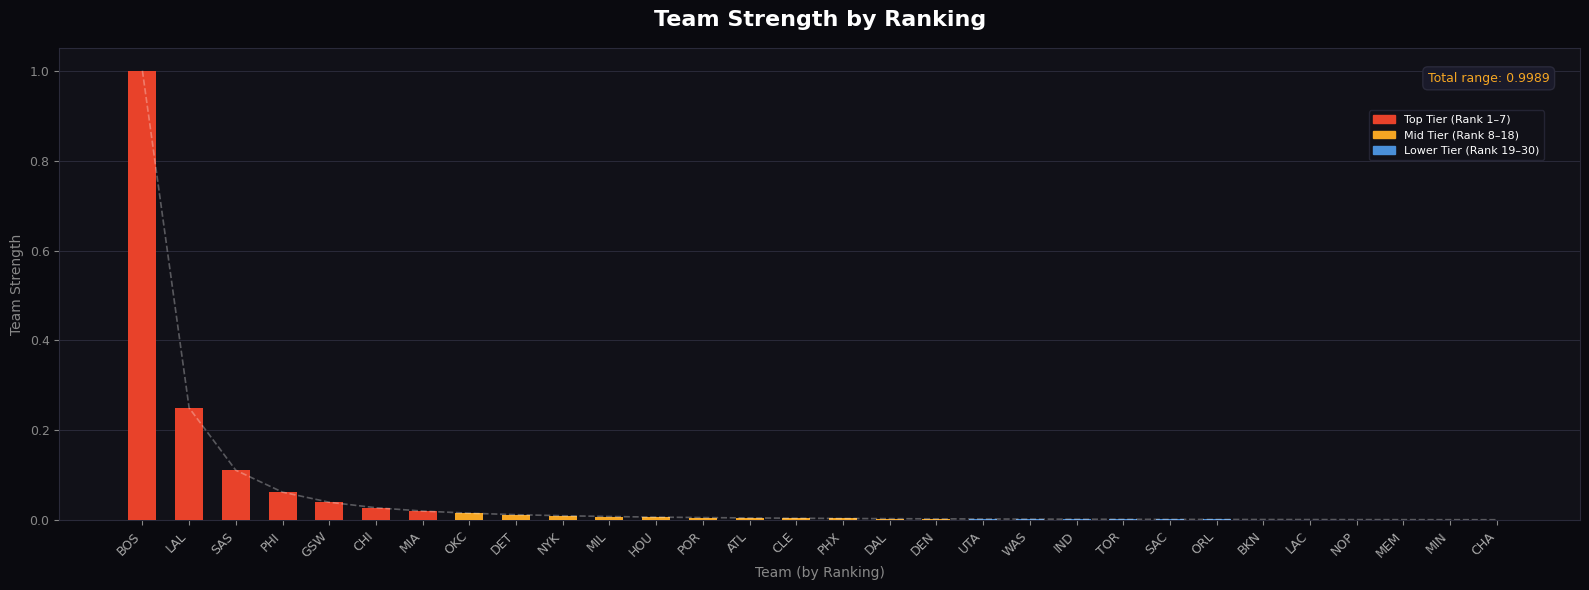

In [25]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

sorted_data = data[['team_rank', 'team_strength']].drop_duplicates().sort_values('team_rank')

team_abbrs = []
for rank in sorted_data['team_rank']:
    abbr = [k for k, v in team_ranking.items() if v == rank][0]
    team_abbrs.append(abbr)

ranks_s    = sorted_data['team_rank'].tolist()
strengths_s = sorted_data['team_strength'].tolist()

fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor('#0a0a0f')
ax.set_facecolor('#111118')

colors = ['#e8422a' if r <= 7 else '#f5a623' if r <= 18 else '#4a90d9' for r in ranks_s]
ax.bar(team_abbrs, strengths_s, color=colors, width=0.6, zorder=3)
ax.plot(team_abbrs, strengths_s, color='white', linewidth=1.2, alpha=0.3, zorder=4, linestyle='--')

ax.tick_params(colors='#888', labelsize=9)
ax.set_xticks(range(len(team_abbrs)))
ax.set_xticklabels(team_abbrs, rotation=45, ha='right', color='#aaa', fontsize=9)
ax.yaxis.set_tick_params(labelcolor='#888')
ax.set_ylabel('Team Strength', color='#888', fontsize=10)
ax.set_xlabel('Team (by Ranking)', color='#888', fontsize=10)
ax.set_title('Team Strength by Ranking', color='white', fontsize=16, fontweight='bold', pad=16)

for spine in ax.spines.values():
    spine.set_edgecolor('#2a2a3a')

ax.yaxis.grid(True, color='#2a2a3a', linewidth=0.7, zorder=0)
ax.set_axisbelow(True)

diff = max(strengths_s) - min(strengths_s)
ax.annotate(f'Total range: {diff:.4f}', xy=(0.98, 0.95), xycoords='axes fraction',
            ha='right', va='top', color='#f5a623', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#1a1a2a', edgecolor='#2a2a3a'))

legend = [
    mpatches.Patch(color='#e8422a', label='Top Tier (Rank 1–7)'),
    mpatches.Patch(color='#f5a623', label='Mid Tier (Rank 8–18)'),
    mpatches.Patch(color='#4a90d9', label='Lower Tier (Rank 19–30)'),
]
ax.legend(handles=legend, facecolor='#111118', edgecolor='#2a2a3a',
          labelcolor='white', fontsize=8, loc='upper right',
          bbox_to_anchor=(0.98, 0.88))

plt.tight_layout()
plt.savefig('team_strength.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0f')
plt.show()

### Team Strength Interpretation

**Key observation:** Team strength drops sharply for the top-ranked teams and then flattens out significantly for the rest. The gap between rank 1 and rank 2 is far larger than the gap between rank 10 and rank 20.

This means elite franchises place disproportionately higher pressure on their drafted players compared to mid or lower tier teams, which are nearly indistinguishable from each other in terms of the pressure they generate. Being drafted by the best team is not just slightly harder — it is exponentially harder to meet expectations.

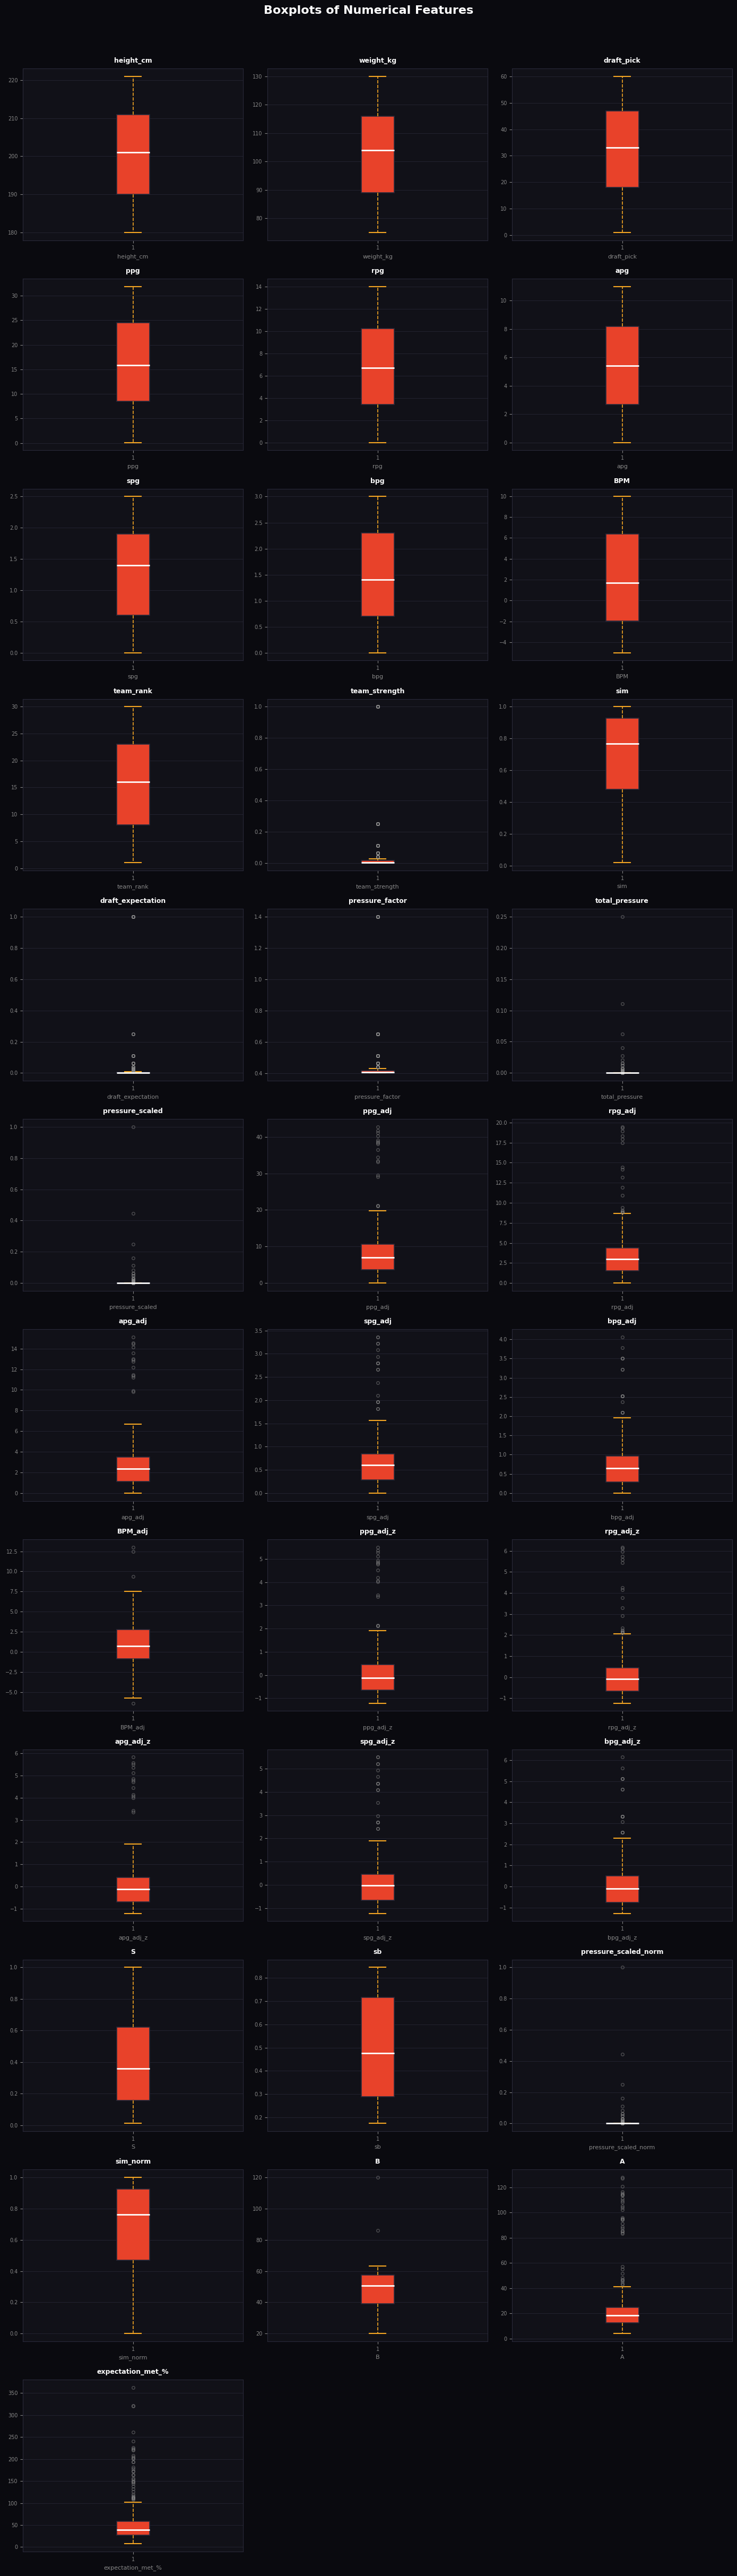

In [26]:
import math

n    = len(numeric_cols)
cols = 3
rows = math.ceil(n / cols)

fig = plt.figure(figsize=(14, 4 * rows))
fig.patch.set_facecolor('#0a0a0f')
fig.suptitle('Boxplots of Numerical Features', color='white', fontsize=16, fontweight='bold', y=1.01)

for i, col in enumerate(numeric_cols):
    ax = fig.add_subplot(rows, cols, i + 1)
    ax.set_facecolor('#111118')

    bp = ax.boxplot(data[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#e8422a', color='#2a2a3a', linewidth=1.2),
                    capprops=dict(color='#f5a623', linewidth=1.5),
                    whiskerprops=dict(color='#f5a623', linewidth=1.2, linestyle='--'),
                    medianprops=dict(color='white', linewidth=2),
                    flierprops=dict(markeredgecolor='#888', marker='o', markersize=4, alpha=0.5))

    ax.set_title(col, color='white', fontsize=9, fontweight='bold', pad=8)
    ax.set_xlabel(col, color='#888', fontsize=8)
    ax.tick_params(colors='#888', labelsize=7)
    ax.xaxis.set_tick_params(labelcolor='#888')
    ax.yaxis.set_tick_params(labelcolor='#888')

    for spine in ax.spines.values():
        spine.set_edgecolor('#2a2a3a')

    ax.yaxis.grid(True, color='#2a2a3a', linewidth=0.5, zorder=0)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

 Exploratory Data Analysis – Boxplot Observations

 Physical Attributes
- **height_cm**: Ranges roughly 185–215 cm, tight IQR suggesting most players fall within a narrow band. A few shorter outliers exist.
- **weight_kg**: Centered around 100 kg with moderate spread. Distribution is fairly symmetric with no extreme outliers.
- **draft_pick**: Heavily right-skewed — most players were picked early (low pick numbers), with a long tail of late picks. Expected for elite prospect data.

 Raw Per-Game Stats
- **ppg**: Wide spread from ~5 to 30+, with the median around 15–17. Several high-scoring outliers above 30.
- **rpg**: Median around 7, moderate spread. A few high-rebounding outliers near 14.
- **apg**: Median around 5–6, right-skewed with outliers reaching 15. Most players cluster in the low range.
- **spg**: Tight distribution centered near 1.5, slightly right-skewed with a few outliers above 2.5.
- **bpg**: Median around 1.2, right-skewed. Most players block under 2 per game, with outliers near 3.
- **BPM**: Centered near 2–3, with a few negative outliers (below -4) indicating below-average performers in the dataset.

 Team & Contextual Features
- **team_rank**: Wide spread from ~5 to 28, median around 15–17. Covers teams across the full standings spectrum.
- **team_strength**: Very tight distribution near 0, with a few outliers around 0.2–0.3. Mostly low variance.
- **sim**: Skewed toward higher values (0.6–0.9), suggesting most players have high similarity scores. A few low outliers near 0.

 Draft & Pressure Features
- **draft_expectation**: Heavily compressed near 0 with a few outliers near 1.0 — most players have low draft expectation scores.
- **pressure_factor**: Tight range around 0.4–1.4, with outliers on the low end. Most players face moderate pressure.
- **total_pressure**: Very tight, clustered near 0.05–0.15 with a couple of outliers near 0.2+.
- **pressure_scaled**: Most values clustered near 0, with outliers up to 0.8. Heavily right-skewed.

 Adjusted Stats (raw × pressure_factor)
- **ppg_adj**: Similar shape to ppg but with more extreme outliers (40+), amplified by pressure scaling.
- **rpg_adj**: Closely mirrors rpg with moderate outliers around 17.5.
- **apg_adj**: Tight IQR with heavy outliers — pressure factor amplifies assist leaders significantly.
- **spg_adj**: Near-identical shape to spg, slightly compressed.
- **bpg_adj**: Similar to bpg with a few high outliers near 4.
- **BPM_adj**: Wider spread than raw BPM, median around 2.5 with outliers on both ends (-5 to 12.5).

 Z-Scored Adjusted Stats
- **ppg_adj_z**: Centered near 0 as expected, with several high outliers above 6–8. Most players fall between -1 and 2.
- **rpg_adj_z**: Tight around 0, outliers up to ~6.
- **apg_adj_z**: Heavy positive outliers reaching 8+, suggesting a few elite passers pull the distribution.
- **spg_adj_z**: Mostly between -1 and 1, with outliers near 5.
- **bpg_adj_z**: Similar to spg_adj_z, compact with a few high outliers.

 Composite Scores
- **S (Sigmoid Performance Score)**: Ranges 0–1, median around 0.5–0.6. Reasonable spread suggesting the score differentiates players well.
- **sb (BPM-based Sigmoid)**: Median around 0.5, slightly right-skewed. Tight IQR indicates most players cluster around average BPM.
- **pressure_scaled_norm**: Most values near 0 with outliers near 0.8 — confirms pressure is a rare but impactful feature.
- **sim_norm**: Wide spread 0–1, median around 0.6. Good distributional coverage.

 Output / Target Variables
- **B (Base Score?)**: Wide range 20–120, median around 40. Right-skewed with a few outliers near 100+.
- **A (Adjusted Score?)**: Similar shape to B, range 20–125, median around 30. Heavy right skew and outliers.
- **expectation_met_%**: Heavily right-skewed with extreme outliers above 300%. Median near 50%, but variance is very high 

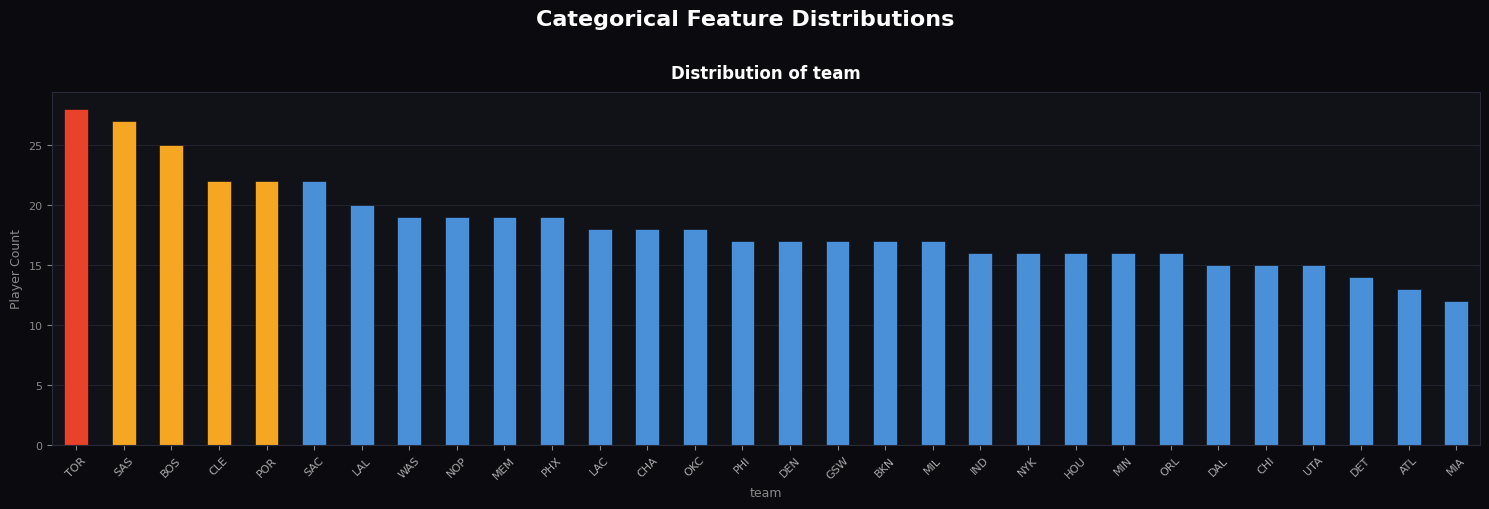

In [27]:
rank_to_abbr = {v: k for k, v in team_ranking.items()}
data['team'] = data['team_rank'].map(rank_to_abbr)

categorical_cols = ['team']

fig, axes = plt.subplots(1, len(categorical_cols), figsize=(15, 5))
fig.patch.set_facecolor('#0a0a0f')
fig.suptitle('Categorical Feature Distributions', color='white', fontsize=16, fontweight='bold', y=1.01)

if len(categorical_cols) == 1:
    axes = [axes]

for i, col in enumerate(categorical_cols):
    ax = axes[i]
    ax.set_facecolor('#111118')

    counts = data[col].value_counts(normalize=False)
    colors = ['#e8422a' if j == 0 else '#f5a623' if j < 5 else '#4a90d9' for j in range(len(counts))]
    counts.plot(kind='bar', ax=ax, color=colors, edgecolor='#0a0a0f', linewidth=0.4)

    ax.set_title(f'Distribution of {col}', color='white', fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel(col, color='#888', fontsize=9)
    ax.set_ylabel('Player Count', color='#888', fontsize=9)
    ax.tick_params(colors='#888', labelsize=8)
    ax.xaxis.set_tick_params(labelcolor='#aaa', rotation=45)
    ax.yaxis.set_tick_params(labelcolor='#888')

    for spine in ax.spines.values():
        spine.set_edgecolor('#2a2a3a')

    ax.yaxis.grid(True, color='#2a2a3a', linewidth=0.5, zorder=0)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

This distribution shows how many players were drafted by each team

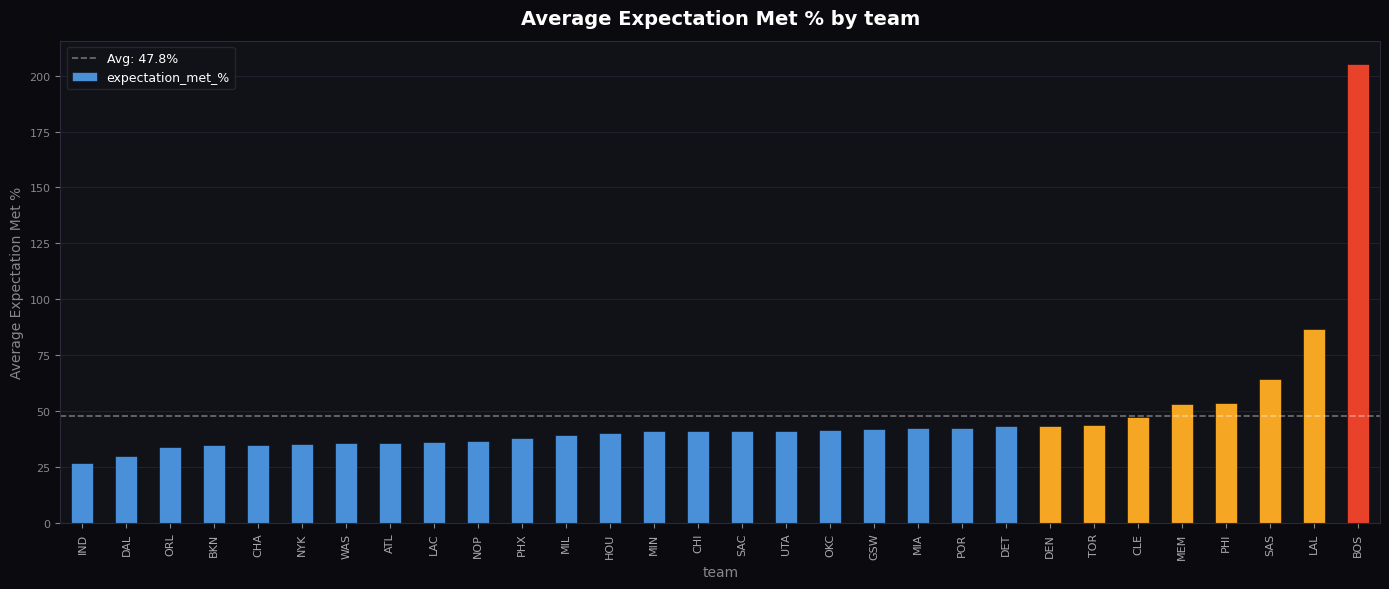

In [28]:
# Mean target by category 
for col in categorical_cols:
    fig, ax = plt.subplots(figsize=(14, 6))
    fig.patch.set_facecolor('#0a0a0f')
    ax.set_facecolor('#111118')

    means = data.groupby(col)['expectation_met_%'].mean().sort_values()
    colors = ['#e8422a' if v == means.max() else '#f5a623' if v >= means.quantile(0.75) else '#4a90d9' for v in means]
    means.plot(kind='bar', ax=ax, color=colors, edgecolor='#0a0a0f', linewidth=0.4)

    ax.axhline(means.mean(), color='white', linewidth=1.2, linestyle='--', alpha=0.4, label=f'Avg: {means.mean():.1f}%')
    ax.legend(facecolor='#111118', edgecolor='#2a2a3a', labelcolor='white', fontsize=9)

    ax.set_title(f'Average Expectation Met % by {col}', color='white', fontsize=14, fontweight='bold', pad=12)
    ax.set_ylabel('Average Expectation Met %', color='#888', fontsize=10)
    ax.set_xlabel(col, color='#888', fontsize=10)
    ax.tick_params(colors='#888', labelsize=8)
    ax.xaxis.set_tick_params(labelcolor='#aaa', rotation=90)
    ax.yaxis.set_tick_params(labelcolor='#888')

    for spine in ax.spines.values():
        spine.set_edgecolor('#2a2a3a')

    ax.yaxis.grid(True, color='#2a2a3a', linewidth=0.5, zorder=0)
    ax.set_axisbelow(True)

    plt.tight_layout()
    
    
    plt.show()

 Average Expectation Met % by Team

The bar chart shows how well players drafted by each team performed relative
to their draft expectations, averaged across all players in the dataset.

 Key Observations

**Outliers on the high end:**
- **BOS (Boston Celtics)** is a massive outlier at ~205%, meaning their drafted
  players dramatically outperformed expectations on average. This could reflect
  smart drafting, strong player development, or a small sample of overachievers.
- **LAL (Los Angeles Lakers)** and **SAS (San Antonio Spurs)** also stand out
  at ~85% and ~65% respectively — both historically known for player development.

**The middle pack (most teams ~35–55%):**
- The majority of teams cluster between 30–55%, suggesting that across the
  league, players tend to fall somewhat short of their draft billing on average.
  This is expected — draft expectations are often optimistic.

**Underperformers:**
- **IND (Indiana Pacers)** has the lowest average at ~25%, meaning their drafted
  players consistently underperformed relative to expectations.
- **DAL (Dallas Mavericks)** and **ORL (Orlando Magic)** follow closely behind.

### Find the correlation of different features with the target variable 

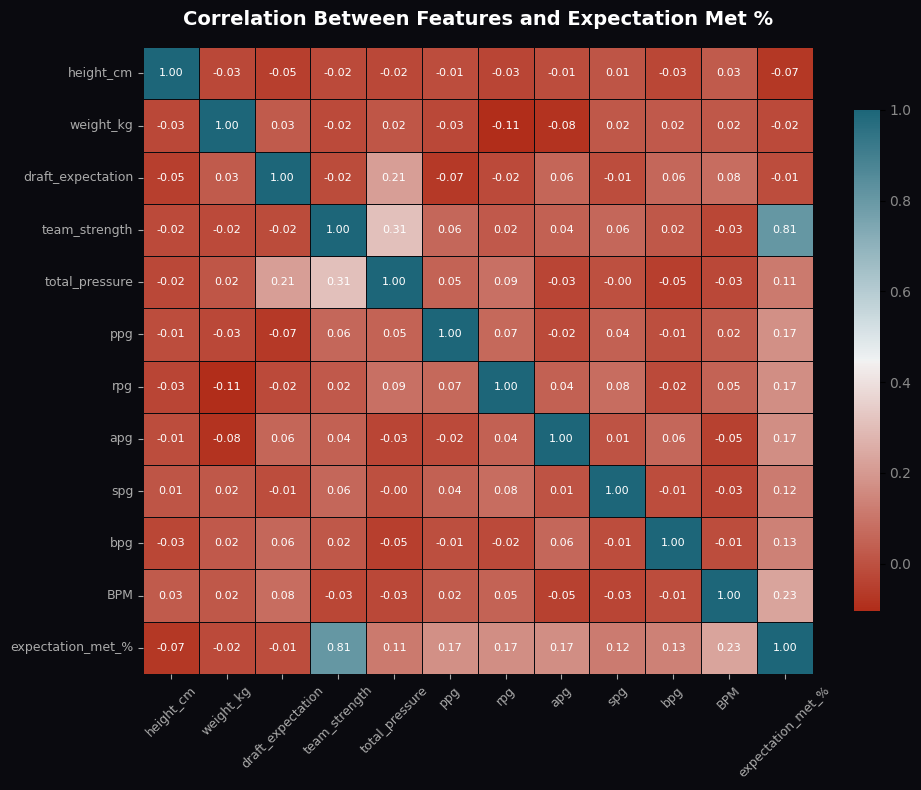

In [31]:

numerical_cols = ['height_cm', 'weight_kg',
    'draft_expectation', 'team_strength', 'total_pressure',
    'ppg', 'rpg', 'apg', 'spg', 'bpg', 'BPM', 'expectation_met_%']

correlation_matrix = data[numerical_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('#0a0a0f')
ax.set_facecolor('#111118')

cmap = sns.diverging_palette(15, 220, s=90, l=40, as_cmap=True)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap=cmap,
    linewidths=0.5,
    linecolor='#0a0a0f',
    ax=ax,
    annot_kws={'size': 8, 'color': 'white'},
    cbar_kws={'shrink': 0.8}
)

ax.set_title('Correlation Between Features and Expectation Met %',
             color='white', fontsize=14, fontweight='bold', pad=16)

ax.tick_params(colors='#aaa', labelsize=9)
ax.xaxis.set_tick_params(labelcolor='#aaa', rotation=45)
ax.yaxis.set_tick_params(labelcolor='#aaa', rotation=0)

cbar = ax.collections[0].colorbar
cbar.ax.yaxis.set_tick_params(labelcolor='#888')
cbar.outline.set_edgecolor('#2a2a3a')

plt.tight_layout()
plt.show()

 ### Interpretation:

team_strength has the most effect on expectations met (which is also correlated to total_pressure) , which shows the importance of having a good supporting cast on your team , because basketball is a team sports, so sometimes the player isn't up to the expectations set because his team isn't the best

## 7. Train/Test Split

We keep a test set aside for final evaluation.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (436, 34)
X_test : (109, 34)
y_train: (436,)
y_test : (109,)


## 8. Build and Compare Multiple Regression Models

We will compare a broad set of regression algorithms:

- Linear-family models
    - Linear Regression
    - Ridge

- Nonlinear
    - Polynomial Regression

- Tree-based and ensemble models
    - Random Forest Regressor


In [ ]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split

# --- Prepare features and target ---

# Drop the original 'team' column if it exists
if 'team' in data.columns:
    data = data.drop('team', axis=1)

# Keep only numeric columns for X
X = data.select_dtypes(include=['number']).drop('expectation_met_%', axis=1)

# Target
y = data['expectation_met_%']

# --- Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Initialize models ---
linear_model = LinearRegression()
ridge_model = Ridge()
rf_model = RandomForestRegressor(random_state=42)

# --- Polynomial features (degree 2) ---
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)
poly_model = LinearRegression()

# --- Train models ---
linear_model.fit(X_train, y_train)
ridge_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
poly_model.fit(X_poly_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
# model evaluation

from sklearn.metrics import mean_squared_error, r2_score

# Make predictions on the test set
y_pred_linear = linear_model.predict(X_test)

# polynomilal regression
X_poly_test = poly.fit_transform(X_test)
y_pred_poly = poly_model.predict(X_poly_test)

# ridge regression
y_pred_ridge = ridge_model.predict(X_test)

# random forest
y_pred_rf = rf_model.predict(X_test)

# Evaluate the models
def evaluate_model(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f'{model_name}:')
    print(f'Mean Squared Error (MSE): {mse:.2f}')
    print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
    print(f'R-squared (R2): {r2:.2f}')
    print('---')

evaluate_model(y_test, y_pred_linear, "Linear Regression")
evaluate_model(y_test, y_pred_poly, "Polynomial Regression")
evaluate_model(y_test, y_pred_ridge, "Ridge Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest Regression")


Linear Regression:
Mean Squared Error (MSE): 561.08
Root Mean Squared Error (RMSE): 23.69
R-squared (R2): 0.72
---
Polynomial Regression:
Mean Squared Error (MSE): 58227746.65
Root Mean Squared Error (RMSE): 7630.71
R-squared (R2): -29561.21
---
Ridge Regression:
Mean Squared Error (MSE): 306.65
Root Mean Squared Error (RMSE): 17.51
R-squared (R2): 0.84
---
Random Forest Regression:
Mean Squared Error (MSE): 232.86
Root Mean Squared Error (RMSE): 15.26
R-squared (R2): 0.88
---


In [ ]:
print(X.columns)


Index(['height_cm', 'weight_kg', 'draft_pick', 'ppg', 'rpg', 'apg', 'spg',
       'bpg', 'BPM', 'team_rank', 'team_strength', 'sim', 'draft_expectation',
       'pressure_factor', 'total_pressure', 'pressure_scaled', 'ppg_adj',
       'rpg_adj', 'apg_adj', 'spg_adj', 'bpg_adj', 'BPM_adj', 'ppg_adj_z',
       'rpg_adj_z', 'apg_adj_z', 'spg_adj_z', 'bpg_adj_z', 'S', 'sb',
       'pressure_scaled_norm', 'sim_norm', 'B', 'A'],
      dtype='str')


## 9. Inference Function

The following function takes raw user inputs and returns a predicted insurance charge.

Expected fields:

height_cm

weight_kg

team

draft_pick

ppg

rpg

apg

spg

bpg

BPM

In [ ]:
print(data.columns.tolist())

['height_cm', 'weight_kg', 'draft_pick', 'ppg', 'rpg', 'apg', 'spg', 'bpg', 'BPM', 'team_rank', 'team_strength', 'sim', 'draft_expectation', 'pressure_factor', 'total_pressure', 'pressure_scaled', 'ppg_adj', 'rpg_adj', 'apg_adj', 'spg_adj', 'bpg_adj', 'BPM_adj', 'ppg_adj_z', 'rpg_adj_z', 'apg_adj_z', 'spg_adj_z', 'bpg_adj_z', 'S', 'sb', 'pressure_scaled_norm', 'sim_norm', 'B', 'A', 'expectation_met_%']


In [ ]:
team_ranking = {
    'BOS': 1, 'LAL': 2, 'SAS': 3, 'PHI': 4, 'GSW': 5,
    'CHI': 6, 'MIA': 7, 'OKC': 8, 'DET': 9, 'NYK': 10,
    'MIL': 11, 'HOU': 12, 'POR': 13, 'ATL': 14, 'CLE': 15,
    'PHX': 16, 'DAL': 17, 'DEN': 18, 'UTA': 19, 'WAS': 20,
    'IND': 21, 'TOR': 22, 'SAC': 23, 'ORL': 24, 'BKN': 25,
    'LAC': 26, 'NOP': 27, 'MEM': 28, 'MIN': 29, 'CHA': 30
}

# --- Feature Engineering ---
height_m = data['height_cm'] / 100
bmi = data['weight_kg'] / (height_m**2)
data['sim'] = np.exp(-((bmi - 25.5)**2)/50)
data['draft_expectation'] = (1 / data['draft_pick']) ** 2
data['pressure_factor'] = 0.4 + data['team_strength']
data['total_pressure'] = data['draft_expectation'] * data['team_strength']
data['pressure_scaled'] = (data['total_pressure'] - data['total_pressure'].min()) / (data['total_pressure'].max() - data['total_pressure'].min())
data['ppg_adj'] = data['ppg'] * data['pressure_factor']
data['rpg_adj'] = data['rpg'] * data['pressure_factor']
data['apg_adj'] = data['apg'] * data['pressure_factor']
data['spg_adj'] = data['spg'] * data['pressure_factor']
data['bpg_adj'] = data['bpg'] * data['pressure_factor']
data['BPM_adj'] = data['BPM'] * data['pressure_factor']
stats = ['ppg_adj', 'rpg_adj', 'apg_adj', 'spg_adj', 'bpg_adj']
data[[s + '_z' for s in stats]] = (data[stats] - data[stats].mean()) / data[stats].std()
Z_sum = data[[s + '_z' for s in stats]].sum(axis=1)
data['S'] = 1 / (1 + np.exp(-Z_sum))
bpm_mean, bpm_std = data['BPM'].mean(), data['BPM'].std()
data['sb'] = 1 / (1 + np.exp(-(data['BPM'] - bpm_mean) / bpm_std))
data['pressure_scaled_norm'] = (data['pressure_scaled'] - data['pressure_scaled'].min()) / (data['pressure_scaled'].max() - data['pressure_scaled'].min())
data['sim_norm'] = (data['sim'] - data['sim'].min()) / (data['sim'].max() - data['sim'].min())
data['B'] = (0.6 * data['pressure_scaled_norm'] + 0.4 * data['sim_norm'])
data['B'] = (data['B'] - data['B'].min()) / (data['B'].max() - data['B'].min())
data['B'] = np.maximum(0.2 + data['B'], 0.05) * 100
data['A'] = (0.5 * data['sb'] + 0.5 * data['S']) * data['pressure_factor'] * 100
data['expectation_met_%'] = (data['A'] / data['B']) * 100

# --- Function to prepare a single player input ---
def prepare_single_input(height_cm, weight_kg, team, draft_pick,
                         ppg, rpg, apg, spg, bpg, BPM):
    team_rank = team_ranking.get(team)
    if team_rank is None:
        raise ValueError(f"Team '{team}' not found in team_ranking")
    team_strength = (team_rank - 30) / (-29) * 0.5
    height_m = height_cm / 100
    bmi = weight_kg / (height_m ** 2)
    sim = np.exp(-((bmi - 25.5) ** 2) / 50)
    draft_expectation = (1 / draft_pick) ** 2
    pressure_factor = 0.4 + team_strength
    total_pressure = draft_expectation * team_strength
    pressure_scaled = (total_pressure - data['total_pressure'].min()) / (data['total_pressure'].max() - data['total_pressure'].min())
    ppg_adj = ppg * pressure_factor
    rpg_adj = rpg * pressure_factor
    apg_adj = apg * pressure_factor
    spg_adj = spg * pressure_factor
    bpg_adj = bpg * pressure_factor
    BPM_adj = BPM * pressure_factor
    stats_cols = ['ppg_adj', 'rpg_adj', 'apg_adj', 'spg_adj', 'bpg_adj']
    train_means = data[stats_cols].mean()
    train_stds = data[stats_cols].std()
    player_vals = np.array([ppg_adj, rpg_adj, apg_adj, spg_adj, bpg_adj])
    Z_sum = ((player_vals - train_means.values) / train_stds.values).sum()
    S = 1 / (1 + np.exp(-Z_sum))
    sb = 1 / (1 + np.exp(-(BPM - data['BPM'].mean()) / data['BPM'].std()))
    pressure_scaled_norm = (pressure_scaled - data['pressure_scaled'].min()) / (data['pressure_scaled'].max() - data['pressure_scaled'].min())
    sim_norm = (sim - data['sim'].min()) / (data['sim'].max() - data['sim'].min())

    row = pd.DataFrame([{
        'sim':                  sim,
        'draft_expectation':    draft_expectation,
        'pressure_factor':      pressure_factor,
        'total_pressure':       total_pressure,
        'pressure_scaled':      pressure_scaled,
        'ppg_adj':              ppg_adj,
        'rpg_adj':              rpg_adj,
        'apg_adj':              apg_adj,
        'spg_adj':              spg_adj,
        'bpg_adj':              bpg_adj,
        'BPM_adj':              BPM_adj,
        'S':                    S,
        'sb':                   sb,
        'pressure_scaled_norm': pressure_scaled_norm,
        'sim_norm':             sim_norm,
    }])
    return row

# --- Function to predict expectation met ---
def predict_expectation_met(height_cm, weight_kg, team, draft_pick,
                            ppg, rpg, apg, spg, bpg, BPM, model):
    sample = prepare_single_input(height_cm, weight_kg, team, draft_pick,
                                  ppg, rpg, apg, spg, bpg, BPM)
    pred = model.predict(sample[numeric_features])[0]
    return float(pred)

# --- Prepare training data ---
numeric_features = [
    'sim', 'draft_expectation', 'pressure_factor', 'total_pressure',
    'pressure_scaled', 'ppg_adj', 'rpg_adj', 'apg_adj', 'spg_adj',
    'bpg_adj', 'BPM_adj', 'S', 'sb', 'pressure_scaled_norm', 'sim_norm'
]

X = data[numeric_features]
y = data['expectation_met_%']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train models
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

ridge_model = Ridge()
ridge_model.fit(X_train, y_train)

rf_model = RandomForestRegressor()
rf_model.fit(X_train, y_train)

# Test models
y_pred_linear = linear_model.predict(X_test)
y_pred_ridge = ridge_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

for name, preds in [("Linear", y_pred_linear), ("Ridge", y_pred_ridge), ("Random Forest", y_pred_rf)]:
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    print(f"{name:15s} | RMSE: {rmse:.4f} | R²: {r2:.4f}")

Linear          | RMSE: 19.7941 | R²: 0.8011
Ridge           | RMSE: 15.9108 | R²: 0.8715
Random Forest   | RMSE: 16.8187 | R²: 0.8564


In [ ]:
def print_class_distribution(y, title="Class Distribution"):
    counts = y.value_counts()
    total = len(y)
    print(f"\n{title}")
    print("-" * 35)
    for cls, count in counts.items():
        pct = (count / total) * 100
        print(f"{cls:20s} | {count:4d} | {pct:.1f}%")
    print("-" * 35)
    print(f"{'Total':20s} | {total:4d} | 100.0%")

def classify_expectation(val):
    if val >= 110:
        return 'Exceeded'
    elif val >= 75:
        return 'Met'
    else:
        return 'Underperformed'

data['expectation_class'] = data['expectation_met_%'].apply(classify_expectation)

print_class_distribution(data['expectation_class'], "Class Distribution Before SMOTE")

from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import cross_val_score

X = data[numeric_features]
y = data['expectation_class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print_class_distribution(pd.Series(y_train_res), "Class Distribution After SMOTE")

models_clf = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Random Forest':       RandomForestClassifier(random_state=42, class_weight='balanced'),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=42),
    'SVM':                 SVC(random_state=42, class_weight='balanced')
}

print("\n" + "=" * 60)
print(f"{'Model':25s} | {'Acc':>5} | {'F1':>5} | {'CV F1':>8}")
print("-" * 60)
for name, model in models_clf.items():
    model.fit(X_train_res, y_train_res)
    preds  = model.predict(X_test)
    acc    = accuracy_score(y_test, preds)
    report = classification_report(y_test, preds, zero_division=0, output_dict=True)
    f1     = report['macro avg']['f1-score']
    cv     = cross_val_score(model, X_train_res, y_train_res, cv=5, scoring='f1_macro').mean()
    print(f"{name:25s} | {acc:>5.2f} | {f1:>5.2f} | {cv:>8.2f}")
print("=" * 60)

log_reg_model = models_clf['Logistic Regression']
clf_model     = models_clf['Random Forest']


Class Distribution Before SMOTE
-----------------------------------
Underperformed       |  462 | 84.8%
Met                  |   46 | 8.4%
Exceeded             |   37 | 6.8%
-----------------------------------
Total                |  545 | 100.0%

Class Distribution After SMOTE
-----------------------------------
Underperformed       |  370 | 33.3%
Exceeded             |  370 | 33.3%
Met                  |  370 | 33.3%
-----------------------------------
Total                | 1110 | 100.0%

Model                     |   Acc |    F1 |    CV F1
------------------------------------------------------------
Logistic Regression       |  0.89 |  0.72 |     0.96
Random Forest             |  0.92 |  0.74 |     0.98
Gradient Boosting         |  0.94 |  0.79 |     0.98
SVM                       |  0.81 |  0.66 |     0.81


In [ ]:
def predict_expectation_class(height_cm, weight_kg, team, draft_pick,
                               ppg, rpg, apg, spg, bpg, BPM, model):
    sample = prepare_single_input(height_cm, weight_kg, team, draft_pick,
                                  ppg, rpg, apg, spg, bpg, BPM)
    pred = model.predict(sample[numeric_features])[0]
    return pred

def predict_player(height_cm, weight_kg, team, draft_pick,
                   ppg, rpg, apg, spg, bpg, BPM):
    
    score = predict_expectation_met(height_cm, weight_kg, team, draft_pick,
                                    ppg, rpg, apg, spg, bpg, BPM, model=ridge_model)
    
    label = classify_expectation(score)
    
    print(f"Expectation Score : {score:.2f}%")
    print(f"Classification    : {label}")
    return score, label
  


In [ ]:
predict_player(
    height_cm=206, weight_kg=93, team='DAL', draft_pick=1,
    ppg=21, rpg=6.7, apg=4.5, spg=1.2, bpg=0.9, BPM=-4.2
)

Expectation Score : 64.00%
Classification    : Underperformed


(63.99857462276801, 'Underperformed')